## Imports

In [3]:
''' Data manipulation'''
import numpy as np
import pandas as pd

''' Data visualization'''
import matplotlib.pyplot as plt
import seaborn as sns

# 🚀 Real Estate - Advanced Estimator


❗️ In the previous task, we couldn't "solve" the equation $\large \boldsymbol X \cdot \boldsymbol \theta = \boldsymbol y $ when the number of apartments in our dataset ($\large n$ observations $\large> p$ features) exceeded the number of features. Without a deterministic formula for $\large \boldsymbol \theta$, we couldn't predict prices for new apartments!


----


🎯 In this exercise, we now have access to a larger dataset of 1000 apartments and want to improve our prediction for the same new apartment as before:


- `Surface`: 3000 $ft^2$


- `Bedrooms`: 5 
- `Floors`: 1


❌ Instead of solving $\large \boldsymbol X \cdot \boldsymbol \theta = \boldsymbol y $ with a **`non-invertible`** matrix $\large \boldsymbol X$ of shape $(1000,4)$...


🚀 ...we will find the vector $\large {\boldsymbol \theta} = \begin{bmatrix}

     \theta_0 \\

     \theta_1 \\

    \theta_2 \\

     \theta_3

\end{bmatrix}_{4 \times 1}$ that minimizes the error $ \large \boldsymbol e = \boldsymbol X \cdot \hat{\boldsymbol \theta} - \boldsymbol y  $.


This is a **`Linear Regression Model`**. We will measure the error $\boldsymbol e$ using the Euclidean distance $\large \left\|\boldsymbol e\right\|$ and the **`Mean Squared Error (MSE)`**.


👉 Let's find an approximate prediction for the new apartment's price by computing $\large \hat{\boldsymbol \theta}$.

## (1) Data Exploration


We load the `flats.csv` dataset below

In [4]:
flats = pd.read_csv('https://d32aokrjazspmn.cloudfront.net/materials/flats.csv')
flats.head(10)

,price,bedrooms,surface,floors
0,274.0,3,1830,2.0
1,500.0,4,2120,1.0
2,320.0,3,1260,1.0
3,445.5,3,1880,1.0
4,637.5,3,1680,1.0
5,460.0,2,2730,1.0
6,259.0,3,1270,1.5
7,950.0,3,2780,1.0
8,550.0,3,1930,2.0
9,265.5,3,1860,1.0


👀 Use `sns.scatterplot()` to visually understand which feature gives the most information about prices:

<Axes: xlabel='surface', ylabel='price'>

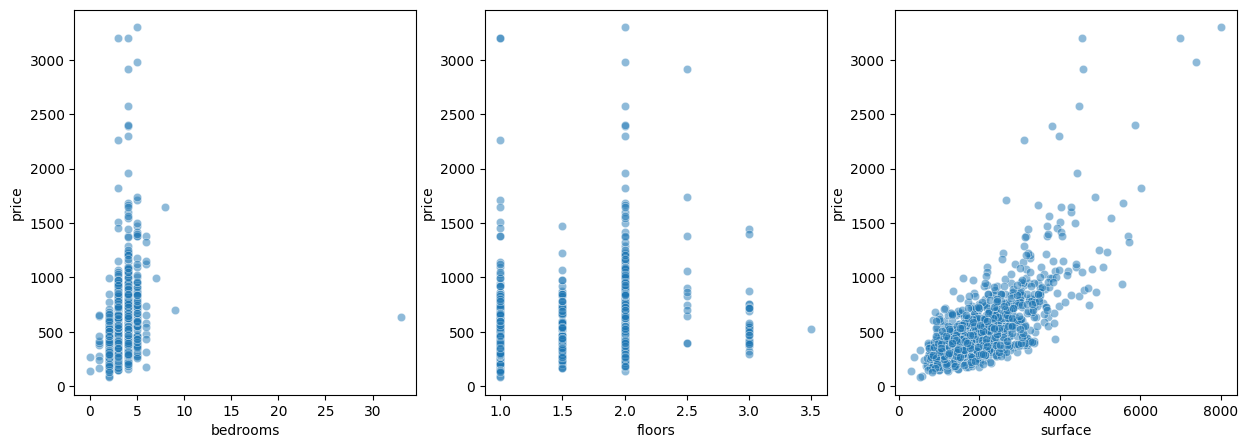

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(x="bedrooms", y="price", data=flats, alpha=0.5, ax=ax1)
sns.scatterplot(x="floors", y="price", data=flats, alpha=0.5, ax=ax2)
sns.scatterplot(x="surface", y="price", data=flats, alpha=0.5, ax=ax3)

👉 It looks like `surface` is a stronger indicator of price than the number of bedrooms or floors. In statistics, we say that `price` is more **correlated** with `surface` than with the other features.


👉 Let's verify this with [`pandas.DataFrame.corr`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html), which computes the correlation coefficients between every pair of columns in the DataFrame.


<i> <u>Notable values:</u></i>

* 1: Two columns are perfectly correlated 📈

* -1: Two columns are perfectly inversely correlated 📉

* 0: Two columns are not *linearly* correlated 😐

    
<details>
    <summary><i>Why use the correlation coefficient instead of covariance?</i></summary>

✅ <u>Similarities</u>:

    
- 📈 Positive correlations and positive covariances: if X increases, Y also increases, and vice versa.
- 📉 Negative correlations and negative covariances: if X increases, Y decreases, and vice versa.
- 🤔 Zero correlation and zero covariance: 
    - They are not _linearly_ related, i.e., no relationship like $ Y = aX + b$.
    - But other relationships may exist such as $Y = X^{2}$ (quadratic), $Y = e^{X}$ (exponential), $Y = ln(X)$ (logarithmic), $Y = sin(\sqrt{1+X^7})$ (very weird).

❗️<u>Key differences</u>:

- 😖 Covariance $ cov(X, Y) \in ( - \infty ; + \infty ) $ and is hard to compare.
    Example: if $ cov (X, Y) = 10 $ and $ cov (X, Z) = 30 $, are X and Z more related? _Not necessarily_, because the units may differ.

    🧑🏻‍🏫 Solution: Use correlation, usually denoted $\rho$.

👉 <u>Conclusion</u>:

- Correlation is the standardized version of covariance: we divide the covariance by the standard deviations of X and Y.
$$ \large  \rho(X,Y) = \frac{cov(X,Y)}{\sigma_X \sigma_Y} \in [0;1]$$

Example: if $ \rho(X, Y) = 0.80 $ and $ \rho(X, Z) = 0.15 $, then X and Y are more correlated!
</details>

In [6]:
flats.corr()

,price,bedrooms,surface,floors
price,1.000000,0.239623,0.732790,0.258263
bedrooms,0.239623,1.000000,0.417170,0.131993
surface,0.732790,0.417170,1.000000,0.357512
floors,0.258263,0.131993,0.357512,1.000000


🎨 You can use a **heatmap** with [`seaborn.heatmap`](https://seaborn.pydata.org/generated/seaborn.heatmap.html) to quickly visualize this matrix.


<details>
    <summary><i>Tips for a prettier correlation matrix</i></summary>

- `cmap`: Since **Seaborn** is a visualization library, you can use the [`cmap`](https://matplotlib.org/stable/tutorials/colors/colormaps.html) argument.
- `annot`: You can display the correlation coefficients directly on the colored map.
- `annot_kws`: You can customize the appearance of the correlation coefficients.
</details>

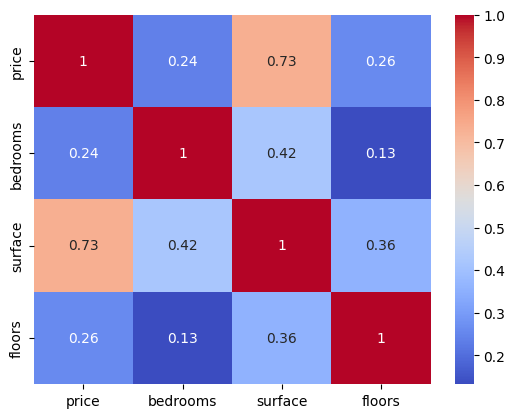

In [7]:
sns.heatmap(
    flats.corr(), 
    cmap='coolwarm', 
    annot=True, 
    annot_kws={'size': 10}
    );

**🧪 Test your code!**

In [9]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'flats',
    shape=flats.shape,
    columns=flats.columns
)

result.write()
print(result.check())

## (2) Univariate Estimator


Let's build a statistical estimator for **price** using only one feature: **surface**.


🎯 We want to fit a **linear regression** between the two variables.


In practice, we want to choose the parameters $\hat{\boldsymbol \theta}$ = (`slope`, `intercept`) such that `predicted_price = slope * surface + intercept` is as close as possible to `price` in terms of Mean Squared Error (MSE).

### (2.1) Visual Approach

❓ Write the `plot_line(slope, intercept)` function


Given `slope` and `intercept` arguments, this function creates a `predicted_price` array and plots it on top of the original (scattered) data.


After writing the function, try playing with different `(slope, intercept)` values to find a "good linear approximation" of the data. Can you find the best fit?


Visual example:


<img src="https://wagon-public-datasets.s3.amazonaws.com/03-Maths/01-Algebra-Calculus/line_of_best_fit.png" width=400>

In [10]:
def plot_line(data, slope, intercept):
    # First, we'll create x - an array of our independent variable values - for you.
    x = data['surface']

    # Now create an array of predicted prices using the predicted prices formula above
    # Remember, we can do mathematical operations on an entire array at once!
    y_pred = x * slope + intercept
    

    # Finally, let's plot the line!
    plt.plot(x, y_pred);

Test your function by running the cell below, then modify the values to find a good line of best fit!


*Tip: You can call `plot_line()` multiple times in the same cell to draw multiple lines on the same scatter plot* 😉

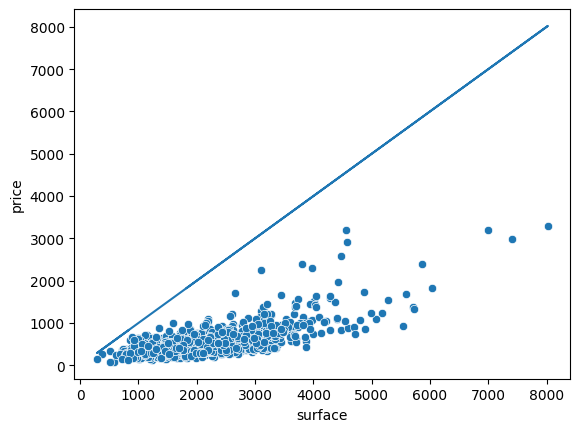

In [19]:
sns.scatterplot(x="surface", y="price", data=flats)
plot_line(flats, 1, 1)

### (2.2) Computational Approach


🔥 To ensure our estimator line is the best, we need to compute the **Mean Squared Error** (MSE) between the **real prices** and the **predicted prices**!


👉 Remember:


- For each apartment: `predicted_price = slope * surface + intercept`


- Both the **real price vector** and the **predicted price vector** have shape $(1000, 1)$

#### (2.2.1) Squared Errors

<u><b>Step 1</b></u>


❓ For each row (_i.e., apartment_), we need to compute `squared_error = (price - predicted_price)**2` ❓

In [16]:
def compute_squared_errors(slope, intercept, surfaces, prices):
    """
    TODO: return an array containing the squared errors between
    all real prices from the dataset and the predicted prices
    """
    
    return (prices - ((slope * surfaces) + intercept)) ** 2

💡 A general principle in Data Science/Modeling: $ \large error = f(\boldsymbol y, \hat{\boldsymbol y})$ where:


- $ \large \boldsymbol y $ is the true value


- $ \large \hat{\boldsymbol y} $ is the predicted value


- $ \large f$ is usually called a **Loss Function** or **Cost Function**
    - 📆 `Machine Learning I > Model Tuning`

#### (2.2.2) Mean Squared Error (MSE)

<u><b>Step 2</b></u>


❓ Create the `mse` function, which should return the mean of the array returned by the `squared_errors` function. ❓

In [17]:
def compute_mse(slope, intercept, surfaces, prices):
    '''TODO: Return the mean of the array contained in squared_errors as a float.'''
    
    errors = compute_squared_errors(slope, intercept, surfaces, prices)
    return np.mean(errors)

👉 In section _(2.1) Visual Approach_, you tried to visually guess the "best line", i.e., the best `(slope, intercept)` pair.


❓ Use this "best pair" to compute the MSE of your estimator. ❓

In [21]:
compute_mse(0.271, -30, flats.surface, flats.price)

np.float64(58527.43021436)

### (2.3) Finding the Best Parameters


👉 Keep playing with different `slope` and `intercept` values and try to get the best fit! Notice how hard it is to optimize two parameters at the same time.


👇 Follow the steps below to see a possible approach:

#### (2.3.1) Finding the Best Slope

<b><i><u> Step 1 :</u></i></b>


Fix your best guess for `initial_intercept`, then find the slope that approximately minimizes the function `mse = f(slope)`

In [24]:
# Define an initial_intercept, for instance, we may suppose there is always a small transaction fee even for very small flats
initial_intercept = 30

In [25]:
# Create a range of 100 slopes that contains what you believe is the optimal slope (hint: np.linspace())
slope_range = np.linspace(0, 0.7, 100)

In [26]:
# Create the list of MSEs for each slope value
mses = list(map(lambda x: compute_mse(x, initial_intercept, flats.surface, flats.price), slope_range))

❓ Plot the MSEs against the slopes. Do you see a minimum? ❓


🙃 If not, try another range of slopes!

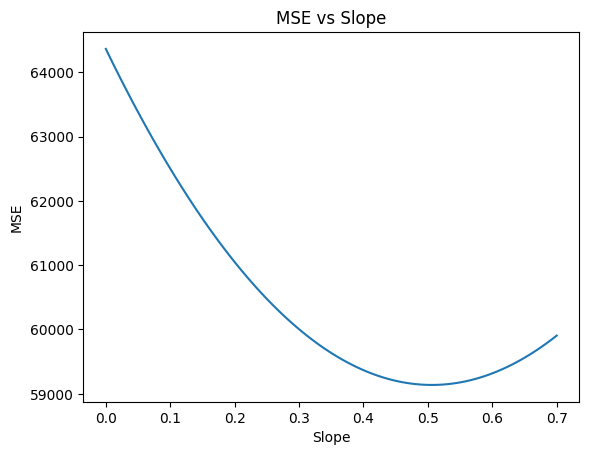

In [31]:
plt.plot(slope_range, mses)
plt.xlabel('Slope')
plt.ylabel('MSE')
plt.title('MSE vs Slope');

❓ Compute the minimum value of the MSE and the corresponding `slope_best` for the `initial_intercept` ❓


<details>
    <summary><i>Hint</i></summary>
    
You can use Python's built-in `.min()` function and the `List.index()` method here
    
</details>

In [28]:
mse_min = min(mses)
slope_best = slope_range[mses.index(mse_min)]

print(f"Minimum MSE: {mse_min}")
print(f"Best Slope: {slope_best}")

Minimum MSE: 59197.19095882538
Best Slope: 0.24747474747474746


#### (2.3.2) Finding the Best Intercept

<b><i><u> Step 2 :</u></i></b>


🔨 Now, fix the slope to `slope_best` and use the same approach as before to find the "best" `intercept_best` value.

In [29]:
# Create a range of 100 intercepts that contains what you believe is the optimal intercept
intercept_range = np.linspace(-50, 50, 100)

In [30]:
# Create the list of MSEs for each intercept value
mses = list(map(lambda x: compute_mse(slope_best, x, flats.surface, flats.price), intercept_range)) 

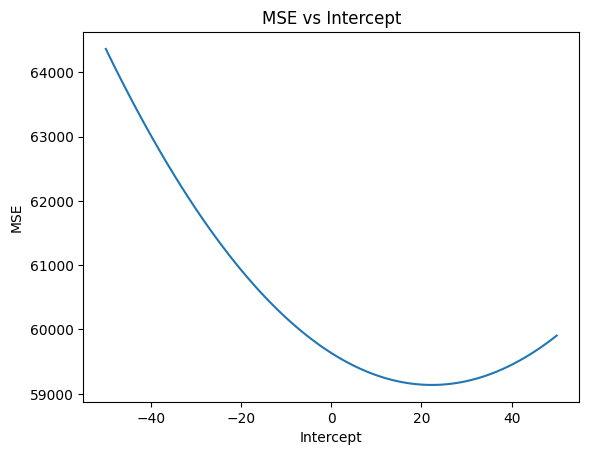

In [ ]:
# Plot MSEs against intercepts. Do you see a minimum? If not, try another range of slopes!
plt.plot(intercept_range, mses)
plt.xlabel('Intercept')
plt.ylabel('MSE')
plt.title('MSE vs Intercept');

❓ Compute `mse_min`, the minimum value of the MSEs when the slope is `slope_best`, and the corresponding best intercept as `intercept_best` ❓



In [34]:
mse_min = None
intercept_best = None

In [35]:
mse_min = min(mses)
intercept_best = intercept_range[mses.index(mse_min)]

print(f"Minimum MSE: {mse_min}")
print(f"Best Intercept: {intercept_best}")

Minimum MSE: 59137.948260276244
Best Intercept: 22.727272727272734


**🧪 Test your code!**

In [36]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'univariate',
    mse_min=mse_min,
    slope_best=slope_best,
    intercept_best=intercept_best
)

result.write()
print(result.check())

🎉 **Great work**! By adding a non-zero intercept parameter, we further reduced the MSE (you can plot the regression line on your scatter plot to visually verify the better fit).


❓ But what guarantees that these (`intercept_best`, `slope_best`) parameters are truly the best values? 

<details>
    <summary>👀 Explanations (<strong>read this carefully!</strong>)</summary>


We could perhaps repeat step ①, this time fixing the intercept to `intercept_best`, then repeat step ② with the new slope to find a better slope value.


To find the global minimum of a two-parameter function `rmse = f(slope, intercept)`, we might need to repeat steps ① and ② indefinitely — with no guarantee of success.


<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/decision-science/real-estate-minimizer.png'>


💪 You've discovered one of the most fundamental aspects of Machine Learning: **the iterative nature of the minimization process**.


👉 As you might expect, algorithms have been developed in the Data Science world to automate and optimize these types of processes. In the next units, you'll discover the power of algorithms like **Gradient Descent**, which perform this iteration for you.
</details>

👉 If you're curious and want to find the true best slope and intercept for this dataset, run the cells below.

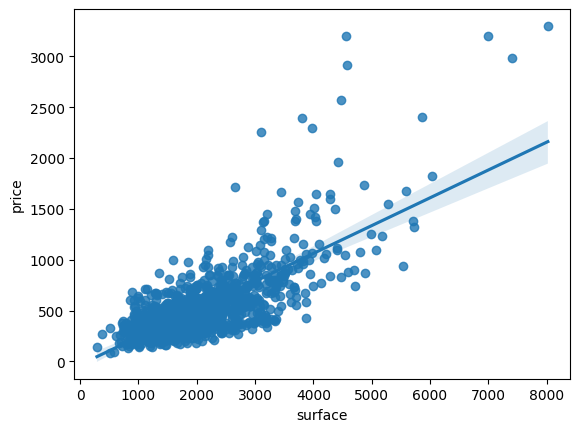

In [37]:
# Try this out (Seaborn visual solution)
sns.regplot(data=flats, x='surface', y='price');

In [38]:
# Try this out (statsmodels, exact solution)!
import statsmodels.formula.api as smf

regression = smf.ols(formula= 'price ~ surface', data=flats).fit()

print("intercept_best", regression.params['Intercept'])
print("slope_best", regression.params['surface'])
print('mse_best: ', np.mean(regression.resid**2))

intercept_best -33.30833598535606
slope_best 0.27369043218689093
mse_best:  58515.1239094964


❓ Let's go back to our initial question: What is your new prediction for the 5th apartment below? How does it compare to your initial prediction based on only 4 apartments?


- `surface`: 3000 $ft^2$


- `bedrooms`: 5 
- `floors`: 1

In [39]:
# compute predicted price (Remember that the real price is 750,000$)
print("predicted_price :" , regression.params["surface"] * 3000 + regression.params["Intercept"])

predicted_price : 787.7629605753167


☝️ Better than our initial deterministic estimator based on only 4 apartments, but we're missing the information provided by the number of bedrooms and floors in this estimate!

## (3) Estimator with _All_ Features (`surface`, `bedrooms`, `floors`)?

💡 A three-feature linear regression (**Multivariate Linear Regression**) works the same way as the single-feature one, but we need to find 4 parameters instead of just 2 to minimize the RMSE: $\hat{\boldsymbol \theta}$ = (`intercept`, `slope_surface`, `slope_bedrooms`, `slope_floors`).


🗓 The Ordinary Least Squares regression can be computed with a closed-form analytical solution (you'll see in the next section), but it can be computationally complex.


🗓 That's why iterative methods like **Gradient Descent** mentioned above are generally used. It's a very powerful and important method in Machine Learning.


👉 In the meantime, you can see the final result of this multivariate regression by running the cell below:

In [40]:
# Find the four regression coefficients by running this cell
regression = smf.ols(formula= 'price ~ surface + bedrooms + floors', data=flats).fit()
regression.params

Intercept    18.154854
surface       0.286953
bedrooms    -21.623564
floors       -3.811868
dtype: float64

🎉 $\boldsymbol {\hat \theta}= \begin{bmatrix}
     \theta_0 \\
     \theta_1 \\
    \theta_2 \\
     \theta_3 \\
\end{bmatrix}_{4 \times 1} = 
\begin{bmatrix}
     \theta_{intercept} \\
     \theta_{surface}\\
    \theta_{bedrooms} \\
     \theta_{floors}
\end{bmatrix}_{4 \times 1} = 
\begin{bmatrix}
    18.154854 \\
    0.286953 \\
    -21.623564 \\
    -3.811868
\end{bmatrix}_{4 \times 1}
$, 

now we can predict the price of the new house:
* $3000 ft^2$
* $5$ bedroom
* $1.$ floor

$$ \hat{y_5} = \theta_0 + \theta_1 \times 3000 + \theta_2 \times 5 + \theta_3 \times 1 $$

In [42]:
# Compute the newly predicted price for the 5th flat? Is this prediction better?
regression.params["Intercept"] +\
regression.params["surface"] * 3000 +\
regression.params["bedrooms"] * 5 +\
regression.params["floors"] * 1


np.float64(767.0851073102862)

## (4) Concluding Remarks on Linear Algebra 🧠

This **optimization problem** can be summarized as follows:


- We need to find the vector $\hat{\boldsymbol \theta} = \begin{bmatrix}

     \theta_{intercept} \\

     \theta_{surface}\\

    \theta_{bedrooms} \\

     \theta_{floors}

\end{bmatrix}_{4 \times 1}$.


- We need to find the one that minimizes the error $e = \left\|\boldsymbol X\cdot \hat{\boldsymbol \theta} - \boldsymbol y  \right\|^2$.


- The feature matrix $\boldsymbol X$ [constant, surfaces, floors, bedrooms]  $\begin{bmatrix}

    1 & 620 & 1 & 1 \\

    1 & 3280 & 4 & 2 \\

    ... \\

    1 & 1900 & 2 & 2 \\

    1 & 1320 & 3 & 3

   \end{bmatrix}_{n \times 4}

$


- and the observation vector $\boldsymbol y  = \begin{bmatrix}

           y_{1} \\

           y_{2} \\

           \vdots \\

           y_{1000}

         \end{bmatrix}$ (prices)


Such a $\large \hat{\theta}$ is obtained when the derivatives $\large 2 \boldsymbol X^T\cdot (\boldsymbol X \cdot \hat{\theta}−\boldsymbol y )$ are zero (👉 you can find the proof in the Linear Regression lecture in the Decision Science module). 
    
In other words, we need to solve the linear system $\large (\boldsymbol X^T\cdot \boldsymbol X)\cdot \hat{\boldsymbol \theta}=\boldsymbol X^T \cdot \boldsymbol y $. 
    
This linear system has a unique solution if no column of $\boldsymbol X$ can be expressed as a linear combination of the others: in this case $ \large (\boldsymbol X^T \cdot \boldsymbol X)^{-1}$ is invertible and the minimum is obtained with $\large \hat{\boldsymbol \theta} = (\boldsymbol X^T\cdot \boldsymbol X)^{-1} \cdot \boldsymbol X^T \cdot \boldsymbol y $. Note that $\boldsymbol X$ no longer needs to be square as in the first task 💪.


💥 However, **inverting matrices is computationally complex**. That's why other methods have been developed to find the minimum of a function, such as **Gradient Descent**.
    
📚 For more information, check out [Stats.StackExchange](https://stats.stackexchange.com/a/278779)!
</details>